# Fig: Path length: Infotaxis, mismatch agentHigher scenario: pmax_th=0.95

Reference: 
- `20251230_fig_mismatch_agent_truth_efficiency_comparison.ipynb`
- `20260515_fig_mismatch_agent_truth_efficiency_comparison_agentHigher_pmax0.95.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from data_prep_plot.plot_utils import bar_violinplot_path_length
from data_prep_plot.simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  996
Mean:    left: 42.833  right: 42.038
Median:  left: 37.000  right: 37.000

MWU test
 - different: 0.95574
 - less:      0.47787
 - greater:   0.52216
--------------------------------------------
Samples: left:  989    right:  999
Mean:    left: 42.833  right: 42.932
Median:  left: 37.000  right: 38.000

MWU test
 - different: 0.37858
 - less:      0.18929
 - greater:   0.81073
--------------------------------------------
Samples: left:  989    right: 1000
Mean:    left: 42.833  right: 44.859
Median:  left: 37.000  right: 41.000

MWU test
 - different: 0.03748
 - less:      0.01874
 - greater:   0.98126
--------------------------------------------
Samples: left:  989    right: 1000
Mean:    left: 42.833  right: 45.936
Median:  left: 37.000  right: 40.000

MWU test
 - different: 0.00162
 - less:      0.00081
 - greater:   0.99919
--------------------------------------------


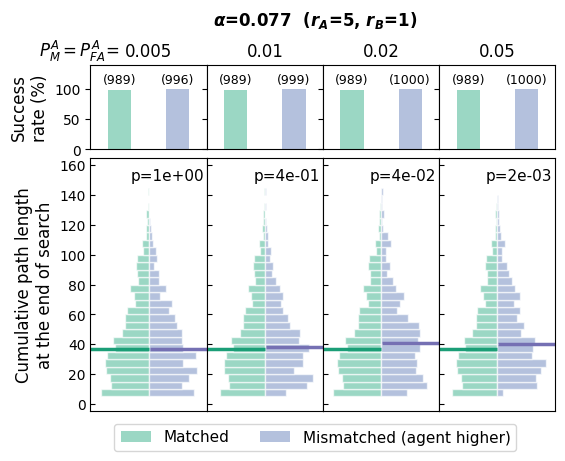

Samples: left:  977    right:  997
Mean:    left: 28.538  right: 30.586
Median:  left: 26.000  right: 28.000

MWU test
 - different: 0.00002
 - less:      0.00001
 - greater:   0.99999
--------------------------------------------
Samples: left:  977    right: 1000
Mean:    left: 28.538  right: 31.260
Median:  left: 26.000  right: 28.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  977    right: 1000
Mean:    left: 28.538  right: 37.043
Median:  left: 26.000  right: 33.500

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  977    right: 1000
Mean:    left: 28.538  right: 59.496
Median:  left: 26.000  right: 57.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


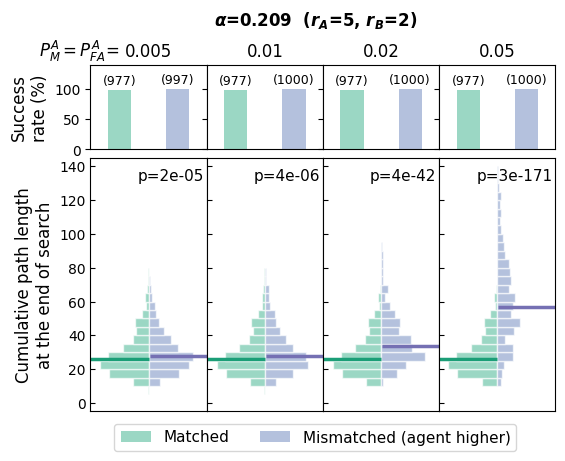

Samples: left:  986    right: 1000
Mean:    left: 253.143  right: 244.311
Median:  left: 226.000  right: 217.000

MWU test
 - different: 0.18543
 - less:      0.90730
 - greater:   0.09272
--------------------------------------------
Samples: left:  986    right: 1000
Mean:    left: 253.143  right: 258.067
Median:  left: 226.000  right: 236.000

MWU test
 - different: 0.61406
 - less:      0.30703
 - greater:   0.69300
--------------------------------------------
Samples: left:  986    right: 1000
Mean:    left: 253.143  right: 248.506
Median:  left: 226.000  right: 223.000

MWU test
 - different: 0.51994
 - less:      0.74006
 - greater:   0.25997
--------------------------------------------
Samples: left:  986    right: 1000
Mean:    left: 253.143  right: 254.907
Median:  left: 226.000  right: 219.500

MWU test
 - different: 0.98380
 - less:      0.49190
 - greater:   0.50813
--------------------------------------------


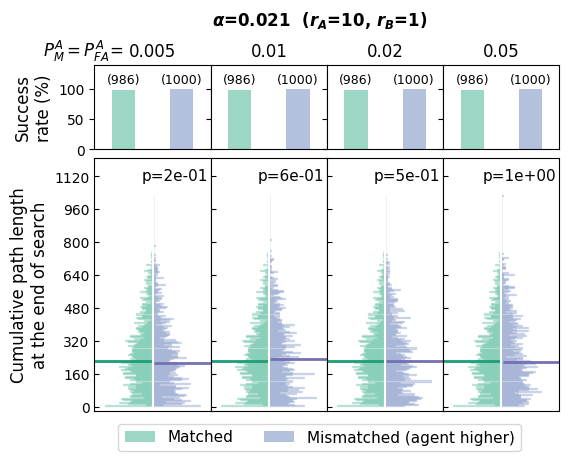

Samples: left:  980    right:  998
Mean:    left: 108.593  right: 109.822
Median:  left: 94.500  right: 93.000

MWU test
 - different: 0.98558
 - less:      0.50724
 - greater:   0.49279
--------------------------------------------
Samples: left:  980    right:  998
Mean:    left: 108.593  right: 108.515
Median:  left: 94.500  right: 91.000

MWU test
 - different: 0.69374
 - less:      0.65316
 - greater:   0.34687
--------------------------------------------
Samples: left:  980    right: 1000
Mean:    left: 108.593  right: 120.262
Median:  left: 94.500  right: 97.000

MWU test
 - different: 0.00613
 - less:      0.00306
 - greater:   0.99694
--------------------------------------------
Samples: left:  980    right: 1000
Mean:    left: 108.593  right: 188.817
Median:  left: 94.500  right: 200.000

MWU test
 - different: 0.00000
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------


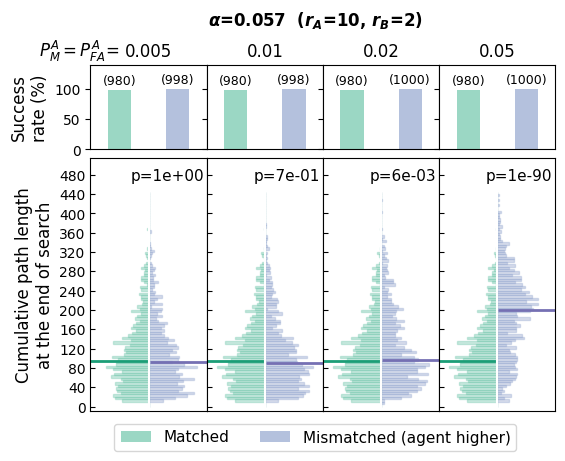

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_agent_all = [0.005, 0.01, 0.02, 0.05]
pm_truth_all = [0.001] * len(pm_agent_all)

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_infotaxis_mismatch_agentHigher_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for idx, (pm_agent, pm_truth) in enumerate(zip(pm_agent_all, pm_truth_all)):
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_truth
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="mismatch",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm_agent, pm_truth=pm_truth
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)

        fig = bar_violinplot_path_length(
            cr=cr, br=br, pm_all=pm_agent_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Matched", y_str="Mismatched (agent higher)",
            stats_type="two-sided",
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            color_idx_left=0, color_idx_right=2,
            print_stats=True,
            comparison_type="agent_higher",
        )

        fig.savefig(
            path_fig / f"fig_path_length_mismatch_agentHigher_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5_infotaxis.png",
            dpi=300, bbox_inches="tight"
        )